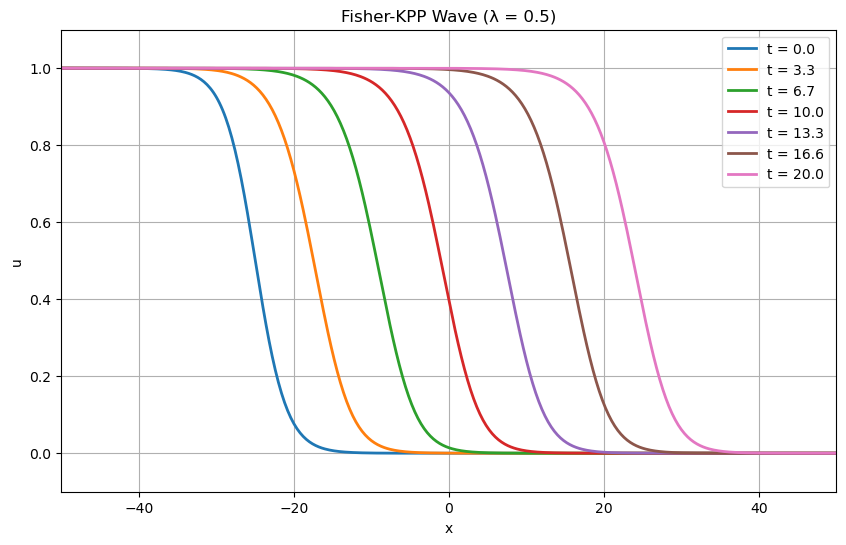

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Setup
L = 50 
nx = 501 
dx = (2 * L) / (nx - 1) 
x = np.linspace(-L, L, nx) 

dt = 0.01 
t_final = 20 
total_steps = int(t_final / dt) 

# Initial Conditions
lam = .5
x0 = -L/2 
u = 1 / (1 + np.exp(lam * (x - x0))) 
u = u.tolist() 

num_plots = 6
plot_every = total_steps // num_plots

plt.figure(figsize=(10, 6))

for step in range(1, total_steps + 1):
    u_new = list(u) 

    # Finite Difference
    for i in range(1, nx - 1): 
        spread = (u[i+1] - 2*u[i] + u[i-1]) / (dx**2)
        growth = u[i] * (1.0 - u[i])
        
        change = (spread + growth) * dt
        u_new[i] = u[i] + change
    
    #Boundary Conditions
    u_new[0] = u_new[1] 
    u_new[nx-1] = u_new[nx-2]
    
    u = u_new
    
    if step % plot_every == 0 or step == 1:
        current_time = step * dt
        plt.plot(x, u, linewidth=2, label='t = ' + str(round(current_time, 1)))

plt.title(f'Fisher-KPP Wave (λ = {lam})')
plt.xlabel('x')
plt.ylabel('u')
plt.axis([-L, L, -0.1, 1.1])
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

In [28]:
import numpy as np
from scipy.stats import linregress

def run_simulation(lam):
    L = 100
    nx = 2001
    dx = (2 * L) / (nx - 1)
    x = np.linspace(-L, L, nx)
    dt = 0.001
    t_final = 50
    total_steps = int(t_final / dt)

    # Initial condition
    x0 = -L/2
    u = 1 / (1 + np.exp(lam * (x - x0)))

    theta = 0.5
    times = []
    positions = []

    for step in range(1, total_steps + 1):
        u_new = np.copy(u)
        
        # Finite Difference
        spread = (u[2:] - 2*u[1:-1] + u[0:-2]) / (dx**2)
        growth = u[1:-1] * (1.0 - u[1:-1])
        u_new[1:-1] = u[1:-1] + (spread + growth) * dt
        
        # Boundary Conditions
        u_new[0] = u_new[1]
        u_new[-1] = u_new[-2]
        u = u_new

        # Find x_theta (where u is 0.5)
        indices = np.where((u[:-1] >= theta) & (u[1:] < theta))[0]
        
        if len(indices) > 0:
            i = indices[-1] # Rightmost crossing point
            
            # Interpolation
            x_interp = x[i] + dx * (u[i] - theta) / (u[i] - u[i+1])
            
            times.append(step * dt)
            positions.append(x_interp)

    # Calculate Speed 
    times = np.array(times)
    positions = np.array(positions)

    if len(times) > 1:
        start_idx = len(times) // 2
        slope, *_ = linregress(times[start_idx:], positions[start_idx:])
        return slope
    else:
        return None

# Table
lambda_values = [0.1, 0.3, 0.5, 0.8, 1, 2, 5, 10, 50]

print(f"{'Lambda (λ)':<12} | {'Wave Speed (c)':<15}")
print("-" * 30)

for l_val in lambda_values:
    speed = run_simulation(l_val)
    if speed is not None:
        print(f"{l_val:<12} | {speed:<15.6f}")
    else:
        print(f"{l_val:<12} | {'Failed'}")

Lambda (λ)   | Wave Speed (c) 
------------------------------
0.1          | 10.139658      
0.3          | 3.641917       
0.5          | 2.499979       
0.8          | 2.049510       
1            | 1.985478       
2            | 1.960907       
5            | 1.959958       
10           | 1.959887       
50           | 1.959867       


Spreading Speed: 1.8988


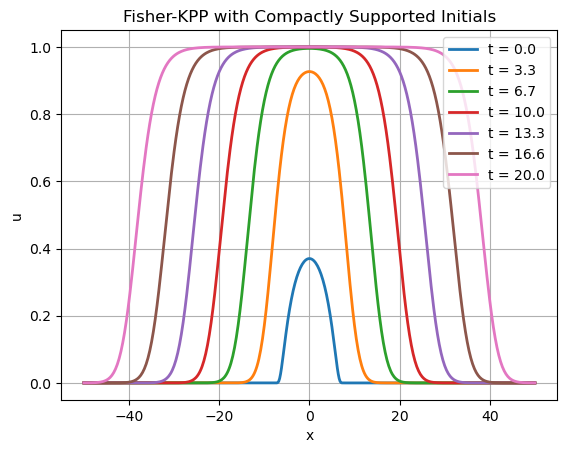

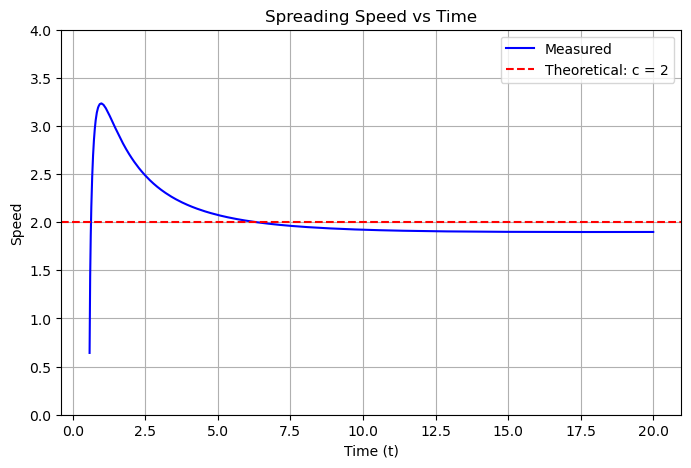

In [42]:
import numpy as np
import matplotlib.pyplot as plt

#Setup
L = 50 
nx = 501 
dx = (2 * L) / (nx - 1) 
x = np.linspace(-L, L, nx) 

dt = 0.01 
t_final = 20 
total_steps = int(t_final / dt) 

# Initial Condition
x0 = 0
a = 7.5
u = [] 
for i in range(nx):
    val_x = x[i]
    if abs(val_x - x0) < a:
        exponent = -1.0 / (1.0 - ((val_x - x0) / a)**2)
        u.append(np.exp(exponent))
    else:
        u.append(0.0)

# Threshold
theta = 0.5
times = []
positions = []

num_plots = 6
plot_every = total_steps // num_plots

for step in range(1, total_steps + 1):
    t_current = step * dt
    
    u_new = list(u) 
        
    for i in range(1, nx - 1):
        
        # Finite Difference
        spread = (u[i+1] - 2*u[i] + u[i-1]) / (dx**2)
        growth = u[i] * (1.0 - u[i])
        u_new[i] = u[i] + (spread + growth) * dt
    
    # Boundary Conditions
    u_new[0] = u_new[1] 
    u_new[nx-1] = u_new[nx-2]
    
    u = u_new
    
    # Find x_theta (where u is 0.5)
    u_arr = np.array(u)
    indices = np.where((u_arr[:-1] >= theta) & (u_arr[1:] < theta))[0]
    
    if len(indices) > 0:
        i = indices[-1] # Rightmost crossing point
        
        # Interpolation
        x_interp = x[i] + dx * (u[i] - theta) / (u[i] - u[i+1])
        
        times.append(step * dt)
        positions.append(x_interp)
    
    if step % plot_every == 0 or step == 1:
        plt.figure(1)
        plt.plot(x, u, linewidth=2, label='t = ' + str(round(t_current, 1)))

times_arr = np.array(times)
pos_arr = np.array(positions)

spreading_speeds = (pos_arr - x0) / times_arr
final_speed = spreading_speeds[-1]


print(f"Spreading Speed: {final_speed:.4f}")

# Plotting
plt.figure(1)
plt.title('Fisher-KPP with Compactly Supported Initials')
plt.xlabel('x')
plt.ylabel('u')
plt.grid(True)
plt.legend(loc='upper right')

plt.figure(2, figsize=(8, 5))
plt.plot(times_arr, spreading_speeds, 'b-', label='Measured')
plt.axhline(y=2.0, color='r', linestyle='--', label='Theoretical: c = 2')
plt.title('Spreading Speed vs Time')
plt.xlabel('Time (t)')
plt.ylabel('Speed')
plt.ylim(0, 4)
plt.grid(True)
plt.legend()

plt.show()

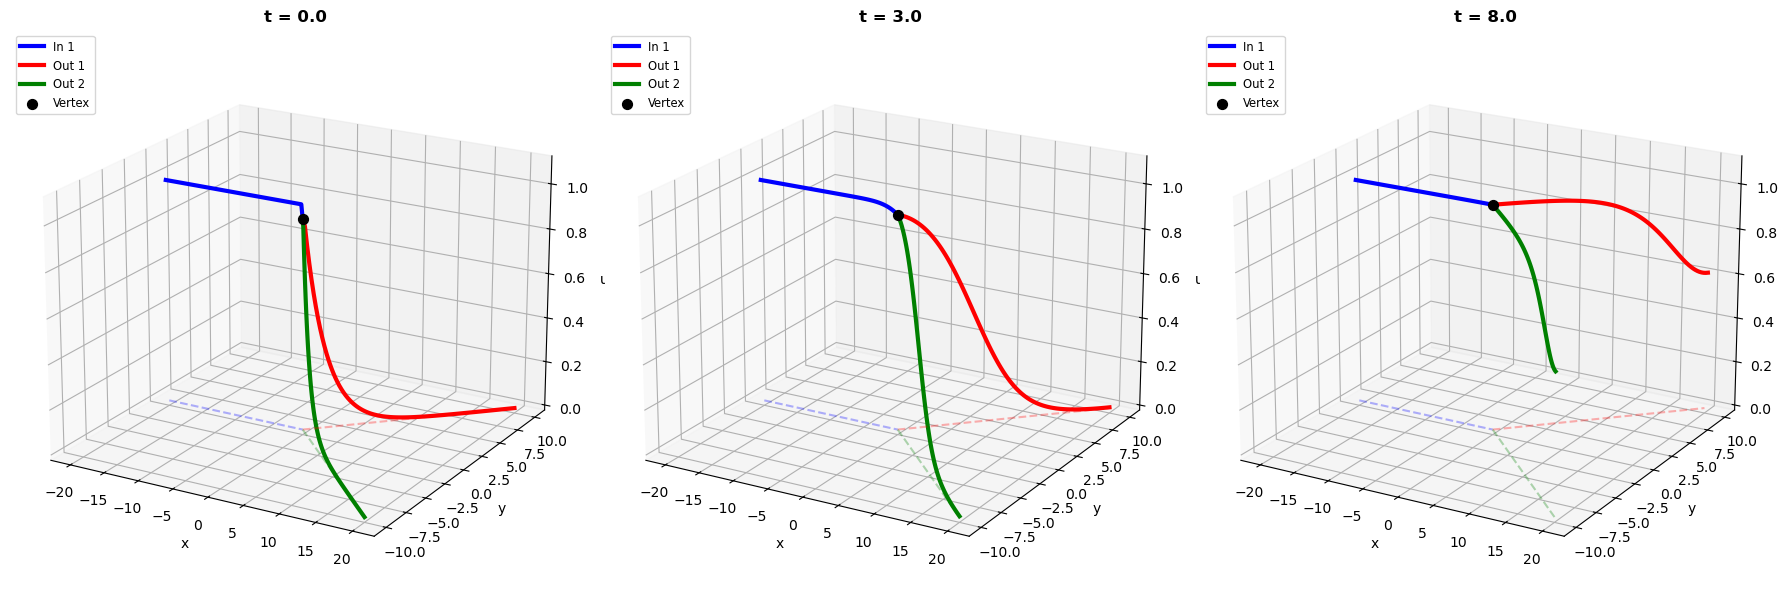

In [34]:
# One in two out

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Setup
L = 20
N = 100
dx = L / N
dt = 0.2 * (dx**2) 
lam = 0.5          
t_final = 10
n_steps = int(t_final / dt)

x_incoming = np.linspace(-L, 0, N + 1)
x_outgoing = np.linspace(0, L, N + 1)

# Initial Conditions
u1 = np.ones(N + 1)
u2 = np.exp(-lam * x_outgoing)
u3 = np.exp(-lam * x_outgoing)

# Vertex 
Uv_init = (u1[-2] + u2[1] + u3[1]) / 3
u1[-1] = u2[0] = u3[0] = Uv_init

# Finite Difference
def get_next_u(u, dx, dt):
    u_new = u.copy()
    diff = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx**2)
    growth = u[1:-1] * (1 - u[1:-1])
    u_new[1:-1] = u[1:-1] + dt * (diff + growth)
    return u_new

snapshots = []
target_times = [0, 3, 8]
current_time = 0

for step in range(n_steps + 1):
    if any(abs(current_time - tt) < dt/2 for tt in target_times):
        snapshots.append((current_time, u1.copy(), u2.copy(), u3.copy()))
    
    u1_n = get_next_u(u1, dx, dt)
    u2_n = get_next_u(u2, dx, dt)
    u3_n = get_next_u(u3, dx, dt)
    
    # Boundary Conditions
    u1_n[0] = u1_n[1]
    u2_n[-1] = u2_n[-2]
    u3_n[-1] = u3_n[-2]
    
    # Vertex Conditions
    Uv = (u1_n[-2] + u2_n[1] + u3_n[1]) / 3
    u1_n[-1] = u2_n[0] = u3_n[0] = Uv
    
    u1, u2, u3 = u1_n, u2_n, u3_n
    current_time += dt

# Graphing
fig = plt.figure(figsize=(18, 6))

for i, (t, s1, s2, s3) in enumerate(snapshots):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # -< shape
    y1 = np.zeros_like(x_incoming)
    y2 = x_outgoing / 2
    y3 = -x_outgoing / 2
    
    # Plotting Curves
    ax.plot(x_incoming, y1, s1, 'b-', lw=3, label='In 1')
    ax.plot(x_outgoing, y2, s2, 'r-', lw=3, label='Out 1')
    ax.plot(x_outgoing, y3, s3, 'g-', lw=3, label='Out 2')

    # Vertex
    ax.scatter([0], [0], [s1[-1]], color='black', s=50, marker='o', label = 'Vertex')
    
    # Projections
    ax.plot(x_incoming, y1, 0, 'b--', alpha=0.3)
    ax.plot(x_outgoing, y2, 0, 'r--', alpha=0.3)
    ax.plot(x_outgoing, y3, 0, 'g--', alpha=0.3)
    
    # Formatting
    ax.set_title(f't = {t:.1f}', fontweight='bold')
    ax.set_zlim(0, 1.1)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u')
    ax.view_init(elev=20, azim=-60)
    ax.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

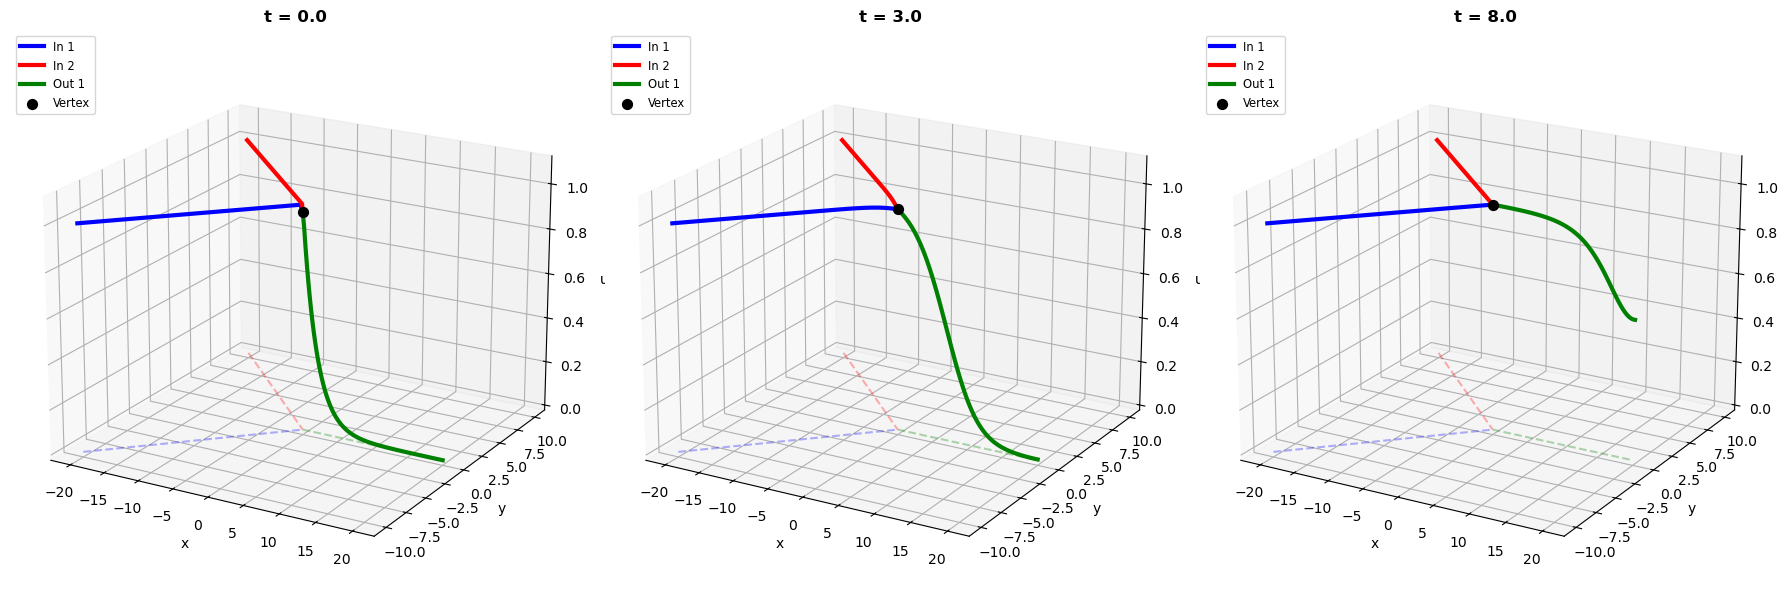

In [35]:
# Two in one out

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

L = 20
N = 100
dx = L / N
dt = 0.2 * (dx**2) 
lam = .5          
t_final = 10
n_steps = int(t_final / dt)

x_in = np.linspace(-L, 0, N + 1)
x_out = np.linspace(0, L, N + 1)

# Initial Condition 
u1 = np.ones(N + 1)         # In 1
u2 = np.ones(N + 1)         # In 2
u3 = np.exp(-lam * x_out)   # Out

# Vertex
Uv_init = (u1[-2] + u2[-2] + u3[1]) / 3
u1[-1] = u2[-1] = u3[0] = Uv_init

# Finite Difference
def get_next_u(u, dx, dt):
    u_new = u.copy()
    diff = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx**2)
    growth = u[1:-1] * (1 - u[1:-1])
    u_new[1:-1] = u[1:-1] + dt * (diff + growth)
    return u_new

snapshots = []
target_times = [0, 3, 8]
current_time = 0

for step in range(n_steps + 1):
    if any(abs(current_time - tt) < dt/2 for tt in target_times):
        snapshots.append((current_time, u1.copy(), u2.copy(), u3.copy()))
    
    u1_n = get_next_u(u1, dx, dt)
    u2_n = get_next_u(u2, dx, dt)
    u3_n = get_next_u(u3, dx, dt)
    
    # Boundary Conditions
    u1_n[0] = u1_n[1]
    u2_n[0] = u2_n[1]
    u3_n[-1] = u3_n[-2]
    
    # Vertex Conditions
    Uv = (u1_n[-2] + u2_n[-2] + u3_n[1]) / 3
    u1_n[-1] = u2_n[-1] = u3_n[0] = Uv
    
    u1, u2, u3 = u1_n, u2_n, u3_n
    current_time += dt

# Graphing
fig = plt.figure(figsize=(18, 6))

for i, (t, s1, s2, s3) in enumerate(snapshots):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # >- shape
    y1 = x_in / 2       
    y2 = -x_in / 2
    y3 = np.zeros_like(x_out)
    
    # Plotting
    ax.plot(x_in, y1, s1, 'b-', lw=3, label='In 1')
    ax.plot(x_in, y2, s2, 'r-', lw=3, label='In 2')
    ax.plot(x_out, y3, s3, 'g-', lw=3, label='Out 1')

    # Vertex
    ax.scatter([0], [0], [s1[-1]], color='black', s=50, marker='o', label = 'Vertex')
    
    # Projections
    ax.plot(x_in, y1, 0, 'b--', alpha=0.3)
    ax.plot(x_in, y2, 0, 'r--', alpha=0.3)
    ax.plot(x_out, y3, 0, 'g--', alpha=0.3)
    
    # Formatting
    ax.set_title(f't = {t:.1f}', fontweight='bold')
    ax.set_zlim(0, 1.1)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u')
    ax.view_init(elev=20, azim=-60)
    ax.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

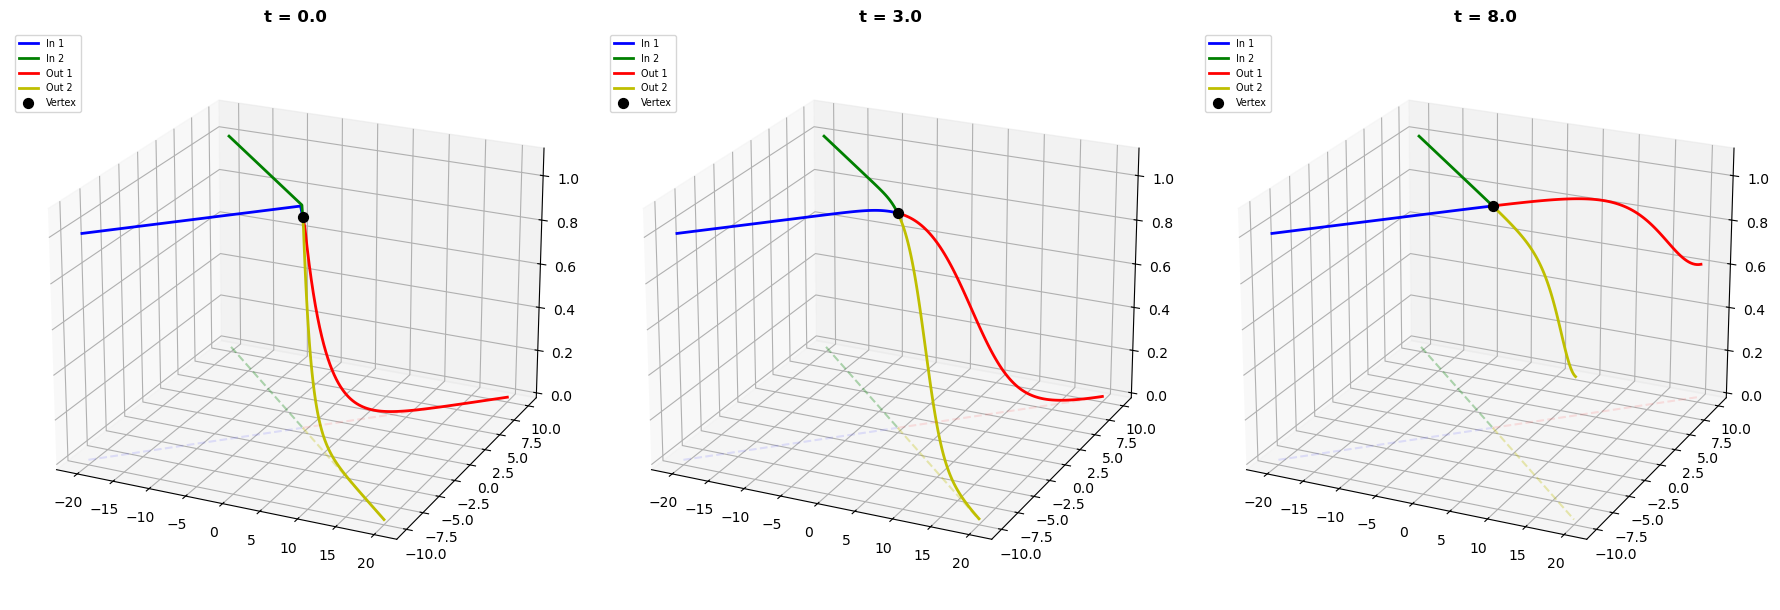

In [36]:
# Two in two out

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Setup
L = 20
N = 100
dx = L / N
dt = 0.2 * (dx**2)
lam = 0.5
t_final = 10
n_steps = int(t_final / dt)

x_in = np.linspace(-L, 0, N + 1)
x_out = np.linspace(0, L, N + 1)

# Initial Conditions
u1 = np.ones(N + 1)           # In 1
u2 = np.ones(N + 1)           # In 2
u3 = np.exp(-lam * x_out)     # Out 1
u4 = np.exp(-lam * x_out)     # Out 2

# Vertex
Uv_init = (u1[-2] + u2[-2] + u3[1] + u4[1]) / 4
u1[-1] = u2[-1] = u3[0] = u4[0] = Uv_init

# Finite Difference
def get_next_u(u, dx, dt):
    u_new = u.copy()
    diff = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx**2)
    growth = u[1:-1] * (1 - u[1:-1])
    u_new[1:-1] = u[1:-1] + dt * (diff + growth)
    return u_new

snapshots = []
target_times = [0, 3, 8]
current_time = 0

for step in range(n_steps + 1):
    if any(abs(current_time - tt) < dt/2 for tt in target_times):
        snapshots.append((current_time, u1.copy(), u2.copy(), u3.copy(), u4.copy()))
    
    u1_n, u2_n = get_next_u(u1, dx, dt), get_next_u(u2, dx, dt)
    u3_n, u4_n = get_next_u(u3, dx, dt), get_next_u(u4, dx, dt)
    
    # Boundary Conditions
    for u_next in [u1_n, u2_n]: u_next[0] = u_next[1]
    for u_next in [u3_n, u4_n]: u_next[-1] = u_next[-2]
    
    # Vertex Conditions
    Uv = (u1_n[-2] + u2_n[-2] + u3_n[1] + u4_n[1]) / 4
    u1_n[-1] = u2_n[-1] = u3_n[0] = u4_n[0] = Uv
    
    u1, u2, u3, u4 = u1_n, u2_n, u3_n, u4_n
    current_time += dt

# Graphing
fig = plt.figure(figsize=(18, 6))

for i, (t, s1, s2, s3, s4) in enumerate(snapshots):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # X-shape
    y1, y2 = x_in / 2, -x_in / 2    # left
    y3, y4 = x_out / 2, -x_out / 2  # right
    
    # Plotting
    ax.plot(x_in, y1, s1, 'b-', lw=2, label='In 1')
    ax.plot(x_in, y2, s2, 'g-', lw=2, label='In 2')
    ax.plot(x_out, y3, s3, 'r-', lw=2, label='Out 1')
    ax.plot(x_out, y4, s4, 'y-', lw=2, label='Out 2')

    # Vertex
    ax.scatter([0], [0], [s1[-1]], color='black', s=50, marker='o', label = 'Vertex')
    
    # Projections
    ax.plot(x_in, y1, 0, 'b--', alpha=0.1); ax.plot(x_in, y2, 0, 'g--', alpha=0.3)
    ax.plot(x_out, y3, 0, 'r--', alpha=0.1); ax.plot(x_out, y4, 0, 'y--', alpha=0.3)

    # Formatting
    ax.set_title(f't = {t:.1f}', fontweight='bold')
    ax.set_zlim(0, 1.1)
    ax.view_init(elev=22, azim=-65)
    ax.legend(loc='upper left', fontsize='x-small')

plt.tight_layout()
plt.show()

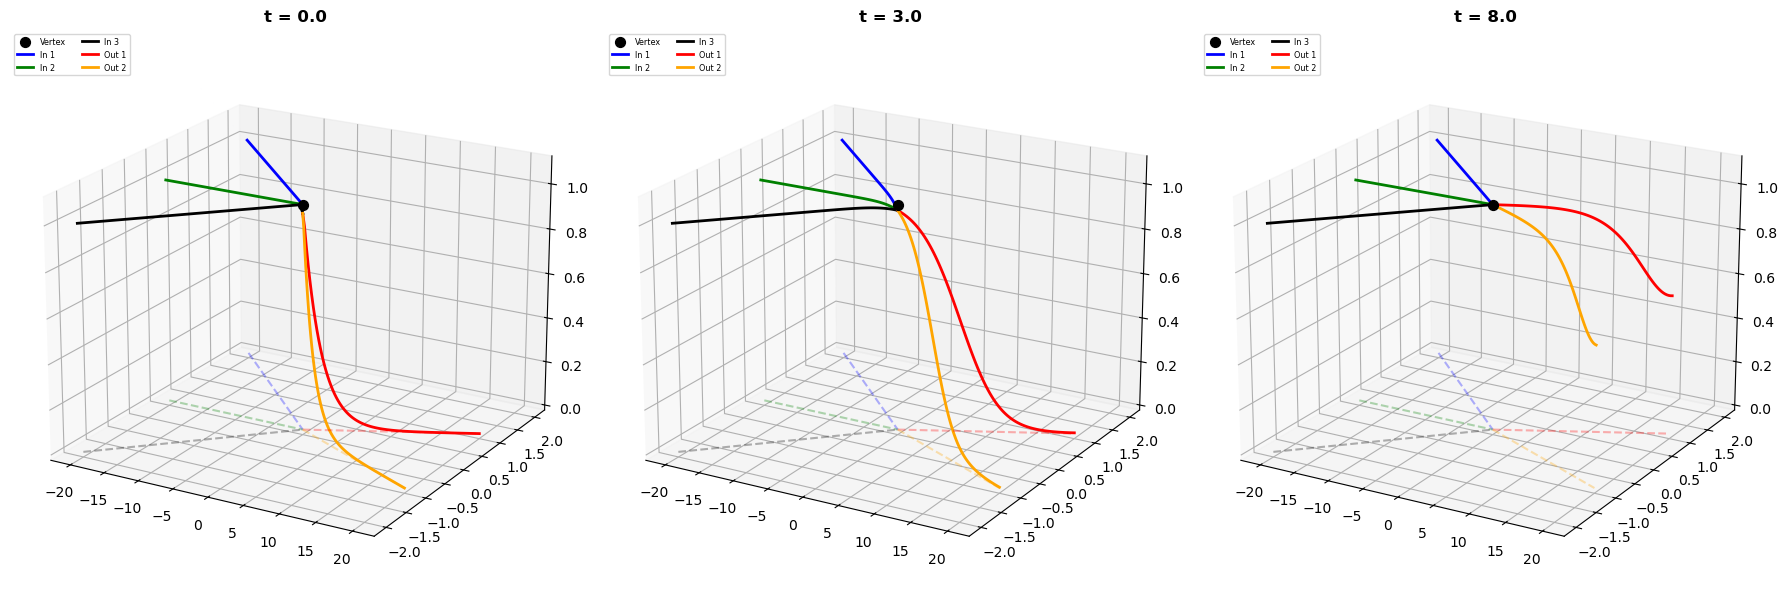

In [38]:
# Three in two out

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Setup
L = 20
N = 100
dx = L / N
dt = 0.2 * (dx**2)
lam = 0.5
t_final = 10
n_steps = int(t_final / dt)

x_in = np.linspace(-L, 0, N + 1)
x_out = np.linspace(0, L, N + 1)

# Initial Conditions
u1 = np.ones(N + 1)           # In 1
u2 = np.ones(N + 1)           # In 2
u3 = np.ones(N + 1)           # In 3
u4 = np.exp(-lam * x_out)     # Out 1
u5 = np.exp(-lam * x_out)     # Out 2

# Vertex
Uv_init = (u1[-2] + u2[-2] + u3[-2] + u4[1] + u5[1]) / 5
u1[-1] = u2[-1] = u3[-1] = u4[0] = u5[0] = Uv_init

# Finite Difference
def get_next_u(u, dx, dt):
    u_new = u.copy()
    diff = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx**2)
    growth = u[1:-1] * (1 - u[1:-1])
    u_new[1:-1] = u[1:-1] + dt * (diff + growth)
    return u_new

snapshots = []
target_times = [0, 3, 8]
current_time = 0

for step in range(n_steps + 1):
    if any(abs(current_time - tt) < dt/2 for tt in target_times):
        snapshots.append((current_time, u1.copy(), u2.copy(), u3.copy(), u4.copy(), u5.copy()))
    
    # Update interior of all 5 edges
    u1_n, u2_n, u3_n = get_next_u(u1, dx, dt), get_next_u(u2, dx, dt), get_next_u(u3, dx, dt)
    u4_n, u5_n = get_next_u(u4, dx, dt), get_next_u(u5, dx, dt)
    
    # Boundary Conditions
    u1_n[0], u2_n[0], u3_n[0] = u1_n[1], u2_n[1], u3_n[1]
    u4_n[-1], u5_n[-1] = u4_n[-2], u5_n[-2]
    
    # Vertex Conditions
    Uv = (u1_n[-2] + u2_n[-2] + u3_n[-2] + u4_n[1] + u5_n[1]) / 5
    u1_n[-1] = u2_n[-1] = u3_n[-1] = u4_n[0] = u5_n[0] = Uv
    
    u1, u2, u3, u4, u5 = u1_n, u2_n, u3_n, u4_n, u5_n
    current_time += dt

# Graphing
fig = plt.figure(figsize=(18, 6))

for i, (t, s1, s2, s3, s4, s5) in enumerate(snapshots):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # Incoming 
    y1 = (x_in / -L) * 2
    y2 = (x_in / -L) * 0
    y3 = (x_in / -L) * -2

    # Outgoing
    y4 = (x_out / L) * 1
    y5 = (x_out / L) * -1
    
    # Vertex
    ax.scatter([0], [0], [u1[-1]], color='black', s=50, marker='o', label = 'Vertex')
    
    # Plotting
    ax.plot(x_in, y1, s1, color='b', lw=2, label='In 1')
    ax.plot(x_in, y2, s2, color='g', lw=2, label='In 2')
    ax.plot(x_in, y3, s3, color='k', lw=2, label='In 3')
    ax.plot(x_out, y4, s4, color='r', lw=2, label='Out 1')
    ax.plot(x_out, y5, s5, color='orange', lw=2, label='Out 2')
        
    # Projections
    for x_arr, y_arr, c in [(x_in, y1, 'b'), (x_in, y2, 'g'), (x_in, y3, 'k'),
                            (x_out, y4, 'r'), (x_out, y5, 'orange')]:
        ax.plot(x_arr, y_arr, 0, color=c, linestyle='--', alpha=0.3)

    # Formatting
    ax.set_title(f't = {t:.1f}', fontweight='bold')
    ax.set_zlim(0, 1.1)
    ax.view_init(elev=20, azim=-60)
    ax.legend(loc='upper left', fontsize='xx-small', ncol=2)

plt.tight_layout()
plt.show()

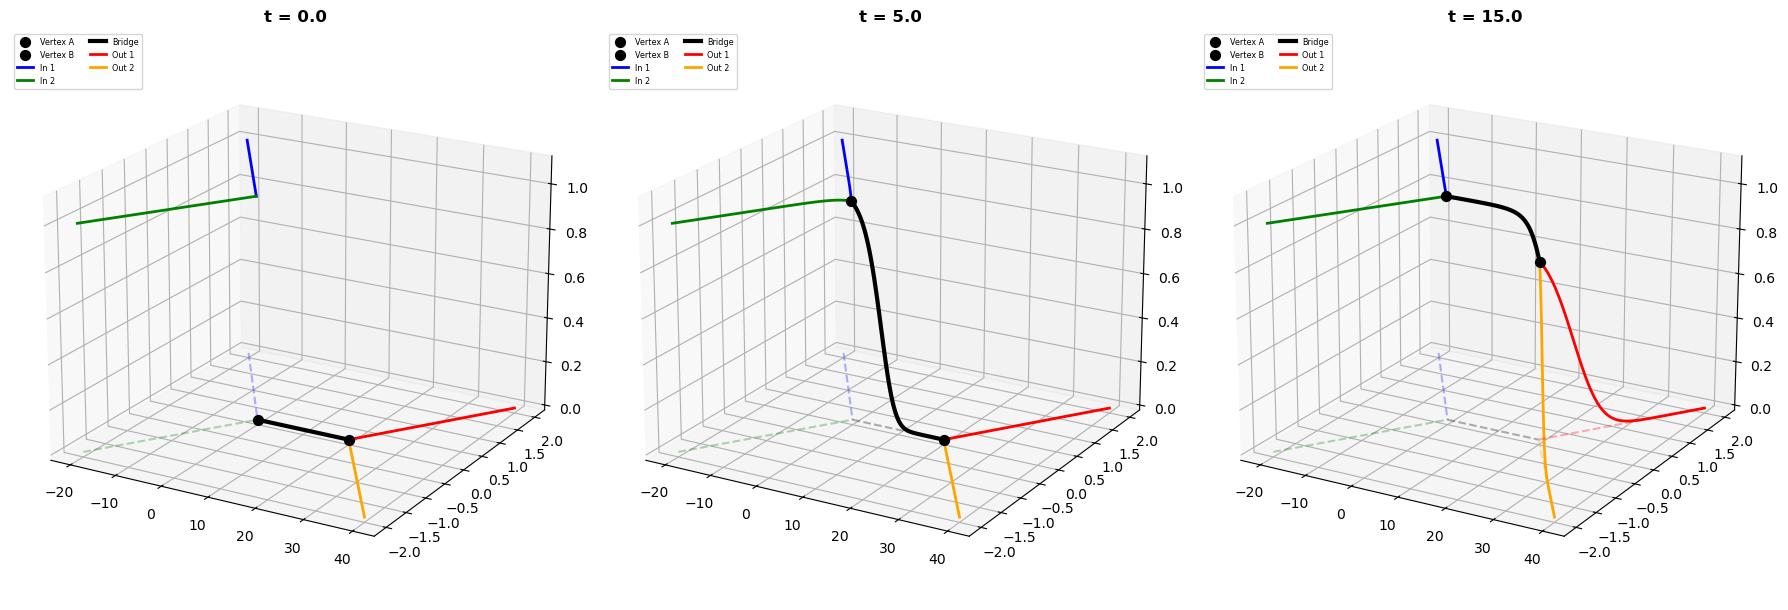

In [80]:
# Two in, bridge, two out

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Setup
L = 20
N = 100
dx = L / N
dt = 0.1 * (dx**2)
lam = 0.5
t_final = 20
n_steps = int(t_final / dt)

x_left = np.linspace(-L, 0, N + 1)   # In 1, 2
x_mid  = np.linspace(0, L, N + 1)    # Bridge
x_right = np.linspace(L, 2*L, N + 1) # Out 1, 2

# Initial Conditions
u1 = np.ones(N + 1)    # In 1
u2 = np.ones(N + 1)    # In 2
u3 = np.zeros(N + 1)   # Bridge
u4 = np.zeros(N + 1)   # Out 1
u5 = np.zeros(N + 1)   # Out 2

# Finite Difference
def get_next_u(u, dx, dt):
    u_new = u.copy()
    diff = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx**2)
    growth = u[1:-1] * (1 - u[1:-1])
    u_new[1:-1] = u[1:-1] + dt * (diff + growth)
    return u_new

snapshots = []
target_times = [0, 5, 15]
current_time = 0

for step in range(n_steps + 1):
    if any(abs(current_time - tt) < dt/2 for tt in target_times):
        snapshots.append((current_time, u1.copy(), u2.copy(), u3.copy(), u4.copy(), u5.copy()))
    
    # Update interior of all 5 edges
    u1_n, u2_n = get_next_u(u1, dx, dt), get_next_u(u2, dx, dt)
    u3_n = get_next_u(u3, dx, dt)
    u4_n, u5_n = get_next_u(u4, dx, dt), get_next_u(u5, dx, dt)
    
    # Boundary Conditions
    u1_n[0], u2_n[0] = u1_n[1], u2_n[1]
    u4_n[-1], u5_n[-1] = u4_n[-2], u5_n[-2]
    
    # Vertex A
    Ua = (u1_n[-2] + u2_n[-2] + u3_n[1]) / 3
    u1_n[-1] = u2_n[-1] = u3_n[0] = Ua
    
    # Vertex B
    Ub = (u3_n[-2] + u4_n[1] + u5_n[1]) / 3
    u3_n[-1] = u4_n[0] = u5_n[0] = Ub
    
    u1, u2, u3, u4, u5 = u1_n, u2_n, u3_n, u4_n, u5_n
    current_time += dt

# Graphing
fig = plt.figure(figsize=(18, 6))

for i, (t, s1, s2, s3, s4, s5) in enumerate(snapshots):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    y1 = (x_left / -L) * 2
    y2 = (x_left / -L) * -2
    y3 = np.zeros_like(x_mid)
    y4 = ((x_right - L) / L) * 2
    y5 = ((x_right - L) / L) * -2

    # Vertices
    ax.scatter([0], [0], [s3[0]], color='black', s=50, marker='o', label='Vertex A')
    ax.scatter([L], [0], [s3[-1]], color='black', s=50, marker='o', label='Vertex B')
    
    # Plotting
    ax.plot(x_left, y1, s1, color='b', lw=2, label='In 1')
    ax.plot(x_left, y2, s2, color='g', lw=2, label='In 2')
    ax.plot(x_mid, y3, s3, color='k', lw=3, label='Bridge')
    ax.plot(x_right, y4, s4, color='r', lw=2, label='Out 1')
    ax.plot(x_right, y5, s5, color='orange', lw=2, label='Out 2')
        
    # Projections
    for x_arr, y_arr, c in [(x_left, y1, 'b'), (x_left, y2, 'g'), (x_mid, y3, 'k'),
                            (x_right, y4, 'r'), (x_right, y5, 'orange')]:
        ax.plot(x_arr, y_arr, 0, color=c, linestyle='--', alpha=0.3)

    # Formatting
    ax.set_title(f't = {t:.1f}', fontweight='bold')
    ax.set_zlim(0, 1.1)
    ax.view_init(elev=20, azim=-60)
    ax.legend(loc='upper left', fontsize='xx-small', ncol=2)

plt.tight_layout()
plt.show()

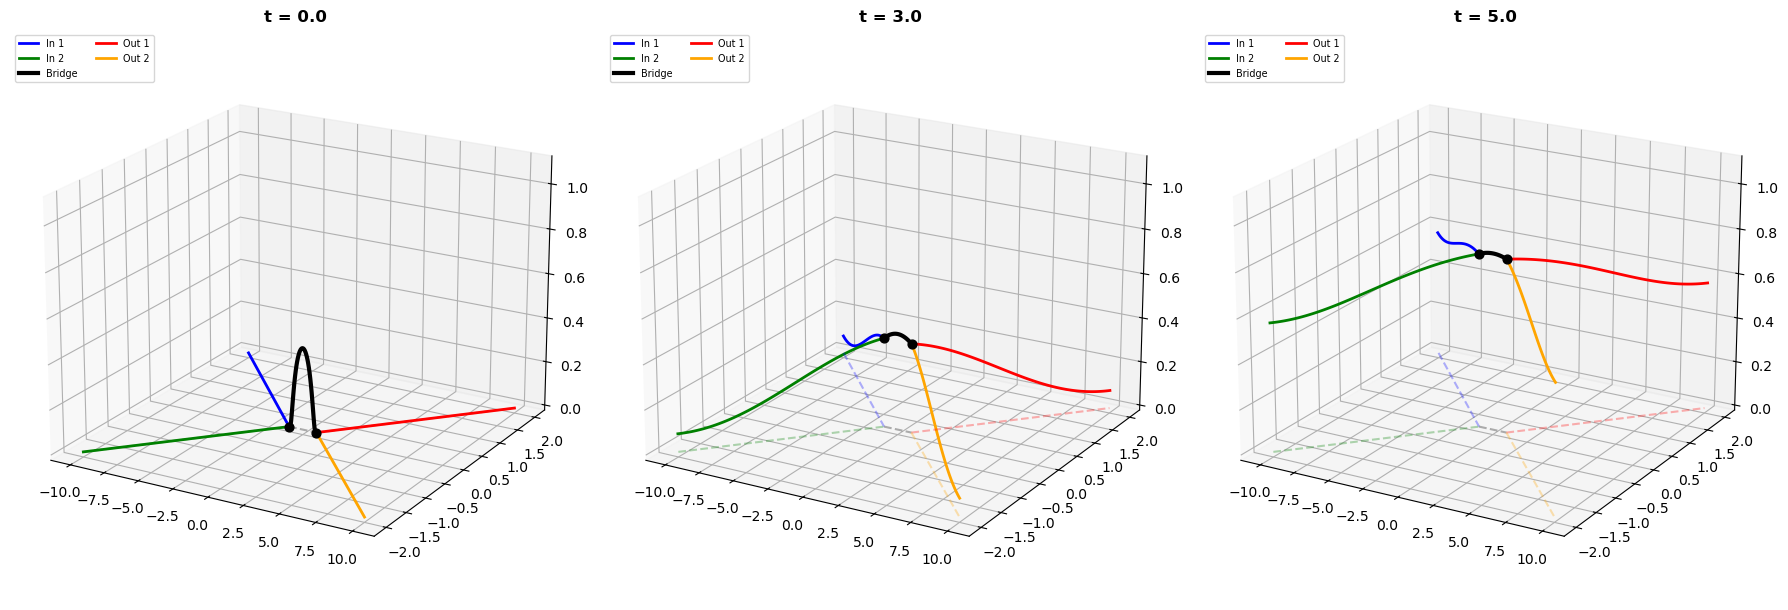

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Setup
L = 10  
N_branch = 100 
N_bridge = 40  
dx = 2.0 / N_bridge
dt = 0.1 * (dx**2)
t_final = 20
n_steps = int(t_final / dt)

x_left = np.linspace(-L, -1, N_branch + 1)
x_mid  = np.linspace(-1, 1, N_bridge + 1)
x_right = np.linspace(1, L, N_branch + 1)

# Initial Conditions
u1, u2 = np.zeros(N_branch + 1), np.zeros(N_branch + 1)
u3 = np.zeros(N_bridge + 1)
u4, u5 = np.zeros(N_branch + 1), np.zeros(N_branch + 1)

x0, a = 0, 1.0
for i in range(len(x_mid)):
    val_x = x_mid[i]
    if abs(val_x - x0) < a:
        exponent = -1.0 / (1.0 - ((val_x - x0) / a)**2)
        u3[i] = np.exp(exponent)

# Finite Difference
def get_next_u(u, dx, dt):
    u_new = u.copy()
    diff = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx**2)
    growth = u[1:-1] * (1 - u[1:-1])
    u_new[1:-1] = u[1:-1] + dt * (diff + growth)
    return u_new

snapshots = []
target_times = [0, 3, 5]
current_time = 0

for step in range(n_steps + 1):
    if any(abs(current_time - tt) < dt/2 for tt in target_times):
        snapshots.append((current_time, u1.copy(), u2.copy(), u3.copy(), u4.copy(), u5.copy()))
    
    u1_n, u2_n = get_next_u(u1, dx, dt), get_next_u(u2, dx, dt)
    u3_n = get_next_u(u3, dx, dt)
    u4_n, u5_n = get_next_u(u4, dx, dt), get_next_u(u5, dx, dt)
    
    # Boundary Conditions
    u1_n[0], u2_n[0] = u1_n[1], u2_n[1]
    u4_n[-1], u5_n[-1] = u4_n[-2], u5_n[-2]
    
    # Vertex A
    Ua = (u1_n[-2] + u2_n[-2] + u3_n[1]) / 3
    u1_n[-1] = u2_n[-1] = u3_n[0] = Ua
    
    # Vertex B
    Ub = (u3_n[-2] + u4_n[1] + u5_n[1]) / 3
    u3_n[-1] = u4_n[0] = u5_n[0] = Ub
    
    u1, u2, u3, u4, u5 = u1_n, u2_n, u3_n, u4_n, u5_n
    current_time += dt

# Graphing
fig = plt.figure(figsize=(18, 6))

for i, (t, s1, s2, s3, s4, s5) in enumerate(snapshots):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    y1 = ((x_left + 1) / ((-L) + 1)) * 2
    y2 = ((x_left + 1) / ((-L) + 1)) * -2
    y3 = np.zeros_like(x_mid)
    y4 = ((x_right - 1) / (L - 1)) * 2
    y5 = ((x_right - 1) / (L - 1)) * -2

    # Plotting
    ax.plot(x_left, y1, s1, color='b', lw=2, label='In 1')
    ax.plot(x_left, y2, s2, color='g', lw=2, label='In 2')
    ax.plot(x_mid, y3, s3, color='k', lw=3, label='Bridge')
    ax.plot(x_right, y4, s4, color='r', lw=2, label='Out 1')
    ax.plot(x_right, y5, s5, color='orange', lw=2, label='Out 2')
    
    # Projections
    for x_arr, y_arr, c in [(x_left, y1, 'b'), (x_left, y2, 'g'), (x_mid, y3, 'k'),
                            (x_right, y4, 'r'), (x_right, y5, 'orange')]:
        ax.plot(x_arr, y_arr, 0, color=c, linestyle='--', alpha=0.3)
    
    # Vertices
    ax.scatter([-1], [0], [s3[0]], color='black', s=40)
    ax.scatter([1], [0], [s3[-1]], color='black', s=40)

    # Formatting
    ax.set_title(f't = {t:.1f}', fontweight='bold')
    ax.set_zlim(0, 1.1)
    ax.view_init(elev=20, azim=-60)
    ax.legend(loc='upper left', fontsize='x-small', ncol=2)

plt.tight_layout()
plt.show()